### Cell 1 — Upload & chuẩn hoá dữ liệu (UTC) + kiểm tra nhanh

- **Mục tiêu:** Đưa `BTC_2019_2023_1d.csv` vào Colab, chuẩn hoá thời gian về **UTC**, ép kiểu số an toàn và đảm bảo dữ liệu sạch trước khi tính chỉ báo/backtest.
- **Các bước chính:**
  1) `files.upload()` → chọn file từ máy, kiểm tra tồn tại `CSV_PATH`.
  2) `read_csv(usecols=...)` → chỉ đọc các cột OHLCV cần thiết.
  3) `to_datetime(format="%d-%m-%Y", utc=True)` → tạo cột `timestamp` chuẩn **UTC**.
  4) Sắp xếp theo thời gian, loại **NaT** và **duplicate** theo `timestamp`.
  5) Ép `open/high/low/close/volume` sang số với `errors="coerce"` (an toàn).
- **Không lookahead:** Chỉ dùng dữ liệu có sẵn tới thời điểm hiện tại; không tham chiếu tương lai.
- **Kiểm tra đầu ra:** In **shape**, **range** thời gian và **NA counts** để xác nhận dữ liệu đã sẵn sàng.

In [ ]:
# CELL 1 — Upload & Load CSV, chuẩn hóa timestamp (UTC) và kiểm tra nhanh
from google.colab import files
import pandas as pd, numpy as np, os

# 1) Upload file CSV (chọn BTC_2019_2023_1d.csv)
uploaded = files.upload()

CSV_FILENAME = "BTC_2019_2023_1d.csv"
CSV_PATH = f"/content/{CSV_FILENAME}"
assert os.path.exists(CSV_PATH), f"Không thấy file: {CSV_PATH}"

# 2) Đọc & chuẩn hóa (không lookahead)
usecols = ["datetime","open","high","low","close","volume"]
df = pd.read_csv(CSV_PATH, usecols=usecols)

# datetime dạng dd-mm-YYYY -> UTC
df["timestamp"] = pd.to_datetime(df["datetime"], format="%d-%m-%Y", utc=True, errors="coerce")
df = (df.drop(columns=["datetime"])
        .sort_values("timestamp")
        .dropna(subset=["timestamp"])
        .drop_duplicates("timestamp"))

# ép numeric an toàn
for c in ["open","high","low","close","volume"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# 3) Kiểm tra nhanh
print("[Shape]", df.shape)
print("[Range]", df["timestamp"].min(), "→", df["timestamp"].max())
print("[NA counts]\n", df[["open","high","low","close","volume","timestamp"]].isna().sum())
df.head(3)


Saving BTC_2019_2023_1d.csv to BTC_2019_2023_1d.csv
[Shape] (1577, 6)
[Range] 2019-09-08 00:00:00+00:00 → 2024-01-01 00:00:00+00:00
[NA counts]
 open         0
high         0
low          0
close        0
volume       0
timestamp    0
dtype: int64


,open,high,low,close,volume,timestamp
0,10000.00,10412.65,10000.00,10391.63,3096.291,2019-09-08 00:00:00+00:00
1,10316.62,10475.54,10077.22,10307.00,14824.373,2019-09-09 00:00:00+00:00
2,10307.00,10382.97,9940.87,10102.02,9068.955,2019-09-10 00:00:00+00:00


### Cell 2 — Core Indicators: RSI, SMA/EMA, Bollinger Bands, Z-score (no lookahead)

- **Mục tiêu:** Tạo bộ chỉ báo nền tảng để xây “strategy components”.
- **Tham số chính:** `SMA(20/50)`, `EMA(12/26)`, `Bollinger(20, k=2)`, `RSI(14)`, `Z-score(20)` — có thể điều chỉnh.

**Định nghĩa ngắn:**
- **SMA(n)**: Trung bình trượt đơn giản của `close` trong `n` phiên → đo xu hướng; có NaN khởi động (`n-1` dòng).
- **EMA(n)**: Trung bình trượt hàm mũ (trọng số gần hiện tại lớn hơn) → nhạy hơn SMA; không NaN đầu do EWMA tích lũy.
- **Bollinger Bands (n, k)**: `MA_n ± k * std_n` → dải biến động quanh trung bình; chạm dải trên/dưới gợi ý quá mua/bán hoặc breakout.
- **RSI(14) — Wilder**: Đo động lượng tăng/giảm gần đây (0–100); >70 quá mua, <30 quá bán. Dùng warm-up 14 phiên nên có 14 NaN đầu.
- **Z-score(n)**: Chuẩn hóa độ lệch so với trung bình trượt `n`: `(close - mean_n)/std_n` → >1/<-1 cho thấy lệch đáng kể.

**Tính chất & an toàn dữ liệu:**
- **No lookahead:** Mọi chỉ báo đều dùng dữ liệu tới thời điểm hiện tại.
- **Warm-up NaN:** Là bình thường (SMA/BB/Z-score: ~`n-1`, RSI: 14). EMA không NaN đầu.
- **Kết quả kiểm tra (log):** Phù hợp kỳ vọng: `sma50=49`, `sma20=19`, `bb_*≈19`, `zscore20=19`, `rsi14=14`, `ema12/26=0`.

**Dùng tiếp:** Các cột mới (`sma*`, `ema*`, `bb_*`, `rsi14`, `zscore20`) sẽ được dùng để tạo **tín hiệu long/short** ở cell kế.


In [9]:
# CELL 2 — Core Indicators (RSI, SMA/EMA, Bollinger Bands, Z-score) — no lookahead
import numpy as np
import pandas as pd

# ---- params (có thể chỉnh) ----
SMA_SHORT, SMA_LONG = 20, 50
EMA_SHORT, EMA_LONG = 12, 26
BB_WIN, BB_K        = 20, 2.0
RSI_N               = 14
ZS_WIN              = 20

def add_indicators(d: pd.DataFrame) -> pd.DataFrame:
    d = d.copy()

    # SMA / EMA
    d[f"sma{SMA_SHORT}"] = d["close"].rolling(SMA_SHORT).mean()
    d[f"sma{SMA_LONG}"]  = d["close"].rolling(SMA_LONG).mean()
    d[f"ema{EMA_SHORT}"] = d["close"].ewm(span=EMA_SHORT, adjust=False).mean()
    d[f"ema{EMA_LONG}"]  = d["close"].ewm(span=EMA_LONG,  adjust=False).mean()

    # Bollinger Bands (close)
    bb_ma = d["close"].rolling(BB_WIN).mean()
    bb_sd = d["close"].rolling(BB_WIN).std(ddof=0)
    d[f"bb_ma_{BB_WIN}"] = bb_ma
    d[f"bb_up_{BB_WIN}"] = bb_ma + BB_K * bb_sd
    d[f"bb_dn_{BB_WIN}"] = bb_ma - BB_K * bb_sd

    # Z-score (close)
    roll_mean = d["close"].rolling(ZS_WIN).mean()
    roll_std  = d["close"].rolling(ZS_WIN).std(ddof=0)
    d[f"zscore{ZS_WIN}"] = (d["close"] - roll_mean) / roll_std.replace(0, np.nan)

    # RSI(14) — Wilder (strict)
    delta = d["close"].diff()
    gain  = delta.clip(lower=0.0)
    loss  = (-delta).clip(lower=0.0)
    avg_gain = gain.rolling(RSI_N, min_periods=RSI_N).mean()
    avg_loss = loss.rolling(RSI_N, min_periods=RSI_N).mean()
    # Wilder recursion
    avg_gain = avg_gain.copy(); avg_loss = avg_loss.copy()
    for i in range(RSI_N + 1, len(d)):
        avg_gain.iat[i] = (avg_gain.iat[i-1]*(RSI_N-1) + gain.iat[i]) / RSI_N
        avg_loss.iat[i] = (avg_loss.iat[i-1]*(RSI_N-1) + loss.iat[i]) / RSI_N
    rs = avg_gain / avg_loss.replace(0, np.nan)
    d[f"rsi{RSI_N}"] = 100 - (100 / (1 + rs))

    return d

df = add_indicators(df)

cols = [f"sma{SMA_SHORT}", f"sma{SMA_LONG}", f"ema{EMA_SHORT}", f"ema{EMA_LONG}",
        f"bb_ma_{BB_WIN}", f"bb_up_{BB_WIN}", f"bb_dn_{BB_WIN}",
        f"zscore{ZS_WIN}", f"rsi{RSI_N}"]

print("[NA (warm-up) các indicator]")
print(df[cols].isna().sum().sort_values(ascending=False))

df[["timestamp","close"] + cols].tail(5)


[NA (warm-up) các indicator]
sma50       49
sma20       19
bb_ma_20    19
bb_dn_20    19
bb_up_20    19
zscore20    19
rsi14       14
ema26        0
ema12        0
dtype: int64


,timestamp,close,sma20,sma50,ema12,ema26,bb_ma_20,bb_up_20,bb_dn_20,zscore20,rsi14
1572,2023-12-28 00:00:00+00:00,42600.1,42870.095,40184.660,42991.323211,42152.154257,42870.095,44578.712412,41161.477588,-0.316039,52.761591
1573,2023-12-29 00:00:00+00:00,42095.1,42788.135,40292.172,42853.442717,42147.928016,42788.135,44480.251157,41096.018843,-0.819134,50.106028
1574,2023-12-30 00:00:00+00:00,42174.2,42706.345,40389.048,42748.943838,42149.874088,42706.345,44350.437544,41062.252456,-0.647342,50.526063
1575,2023-12-31 00:00:00+00:00,42314.0,42758.495,40492.086,42682.029401,42162.031563,42758.495,44278.661330,41238.328670,-0.584798,51.306297
1576,2024-01-01 00:00:00+00:00,44230.2,42894.255,40634.980,42920.209493,42315.229225,42894.255,44430.845290,41357.664710,1.738843,60.501263


### Cell 3 — Tạo tín hiệu Long/Short từ ngưỡng chỉ báo (no lookahead)

- **Mục tiêu:** Biến các chỉ báo thành **tín hiệu giao dịch**: `+1` (Long), `-1` (Short), `0` (Neutral).

**Quy tắc:**
1) **RSI Mean-Reversion**  
   - Nếu `RSI < 30` → **Long**; `RSI > 70` → **Short**; ngược lại **0**.  
   - Ý tưởng: giá quá bán/quá mua có xu hướng hồi về trung bình.

2) **SMA Crossover (Trend-Following)**  
   - `SMA20 > SMA50` → **Long**; `SMA20 < SMA50` → **Short**; bằng nhau → **0**.  
   - Ý tưởng: đường ngắn hạn vượt/lùi so với dài hạn báo hiệu xu hướng.

3) **Z-score (Breakout/Extreme)**  
   - `zscore20 > +1` → **Long** (động lượng dương); `zscore20 < −1` → **Short**.  
   - Có thể đảo dấu nếu muốn chiến lược mean-reversion.

**Chống lookahead:**  
- Dịch toàn bộ tín hiệu **`shift(1)`** để tín hiệu hôm nay **chỉ được dùng** vào lệnh **ngày mai**.

**Kiểm tra tần suất (ví dụ log):**  
- `sig_rsi`: {0:1308, −1:190, +1:78} → RSI chặt chẽ, ít tín hiệu, tập trung vùng cực trị.  
- `sig_sma`: {+1:824, −1:703, 0:49} → bám xu hướng, phát tín hiệu đều hơn.  
- `sig_z`: {0:735, +1:494, −1:347} → nhạy với biến động/đột phá.

> Các tín hiệu này sẽ được dùng ở bước backtest (áp dụng position sizing & tính PnL).


In [ ]:
# CELL 3 — Strategy Components: tín hiệu Long/Short theo ngưỡng (no lookahead)

import numpy as np
import pandas as pd

# --- Tham số ngưỡng (có thể chỉnh) ---
RSI_LOW, RSI_HIGH = 30, 70                     # mean-reversion
SMA_SHORT, SMA_LONG = 20, 50                   # trend-following (đã tính ở cell 2)
BB_WIN = 20                                    # bollinger (đã tính)
ZS_WIN = 20                                    # z-score (đã tính)
Z_LONG, Z_SHORT = -1.0, 1.0                    # breakout/mean-rev tùy chọn

sig = df.copy()

# 1) RSI Mean-Reversion: RSI<30 → Long, RSI>70 → Short, else 0
sig["sig_rsi"] = 0
sig.loc[sig["rsi14"] < RSI_LOW,  "sig_rsi"] = 1
sig.loc[sig["rsi14"] > RSI_HIGH, "sig_rsi"] = -1

# 2) SMA Crossover Trend: SMA20 > SMA50 → Long, < → Short
sig["sig_sma"] = np.where(sig["sma20"] > sig["sma50"], 1,
                   np.where(sig["sma20"] < sig["sma50"], -1, 0))

# 3) Z-score Breakout: zscore > +1 → Long (động lượng), zscore < -1 → Short
#    (hoặc đảo dấu nếu bạn muốn mean-reversion)
sig["sig_z"] = 0
sig.loc[sig[f"zscore{ZS_WIN}"] > Z_SHORT, "sig_z"] = 1
sig.loc[sig[f"zscore{ZS_WIN}"] < Z_LONG,  "sig_z"] = -1

# ---- Chống lookahead: dùng tín hiệu hôm nay để vào lệnh ngày mai ----
for c in ["sig_rsi","sig_sma","sig_z"]:
    sig[c] = sig[c].shift(1)

# Kiểm tra nhanh
print("[Tỷ lệ tín hiệu]")
for c in ["sig_rsi","sig_sma","sig_z"]:
    vc = sig[c].value_counts(dropna=True).to_dict()
    print(c, vc)

sig[["timestamp","close","rsi14","sma20","sma50",f"zscore{ZS_WIN}","sig_rsi","sig_sma","sig_z"]].tail(10)


[Tỷ lệ tín hiệu]
sig_rsi {0.0: 1308, -1.0: 190, 1.0: 78}
sig_sma {1.0: 824, -1.0: 703, 0.0: 49}
sig_z {0.0: 735, 1.0: 494, -1.0: 347}


,timestamp,close,rsi14,sma20,sma50,zscore20,sig_rsi,sig_sma,sig_z
1567,2023-12-23 00:00:00+00:00,43725.2,61.681876,42977.215,39404.122,0.781841,0.0,1.0,1.0
1568,2023-12-24 00:00:00+00:00,43008.4,57.083924,43027.980,39562.896,-0.021061,0.0,1.0,0.0
1569,2023-12-25 00:00:00+00:00,43611.9,59.800908,43004.490,39734.624,0.668616,0.0,1.0,0.0
1570,2023-12-26 00:00:00+00:00,42538.5,53.333421,42942.675,39884.246,-0.451131,0.0,1.0,0.0
1571,2023-12-27 00:00:00+00:00,43453.8,57.549398,42950.565,40045.192,0.559349,0.0,1.0,0.0
1572,2023-12-28 00:00:00+00:00,42600.1,52.761591,42870.095,40184.660,-0.316039,0.0,1.0,0.0
1573,2023-12-29 00:00:00+00:00,42095.1,50.106028,42788.135,40292.172,-0.819134,0.0,1.0,0.0
1574,2023-12-30 00:00:00+00:00,42174.2,50.526063,42706.345,40389.048,-0.647342,0.0,1.0,0.0
1575,2023-12-31 00:00:00+00:00,42314.0,51.306297,42758.495,40492.086,-0.584798,0.0,1.0,0.0
1576,2024-01-01 00:00:00+00:00,44230.2,60.501263,42894.255,40634.980,1.738843,0.0,1.0,0.0


### Cell 4 — Trực quan tín hiệu: SMA cross, RSI, Z-score

- **Mục tiêu:** Kiểm tra nhanh tín hiệu hoạt động đúng logic trên đoạn dữ liệu ~365 ngày gần nhất.
- **SMA20 vs SMA50:** Quan sát **cắt lên/cắt xuống** để xác nhận điểm chuyển xu hướng (trend-following).
- **RSI(14):** Vẽ cùng **bands 30/70** và đánh dấu điểm vào/ra theo `sig_rsi` (đã **shift(1)** để tránh lookahead).
- **Z-score(20):** Vẽ ngưỡng **±1** và chấm các điểm `sig_z` để thấy các cú **breakout/mean-rev**.
- **Lợi ích:** Giúp leader nhìn được **tín hiệu ↔ đồ thị** có khớp quy tắc đã định không trước khi backtest.


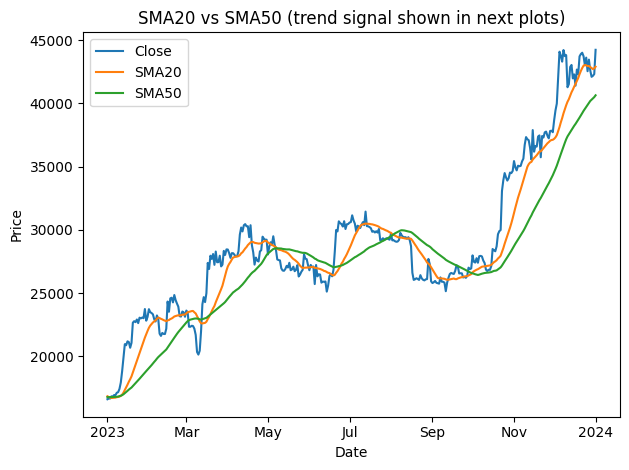

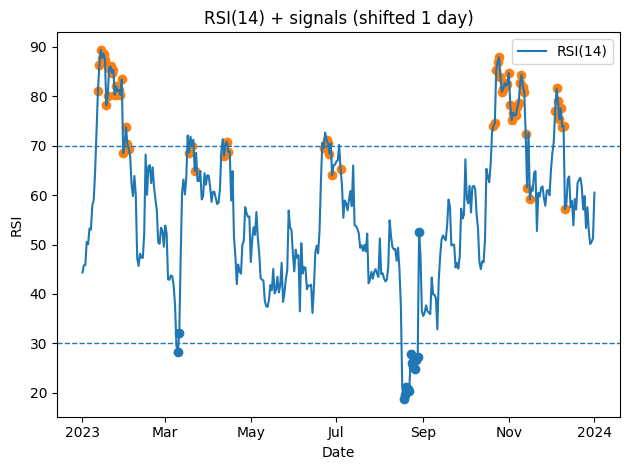

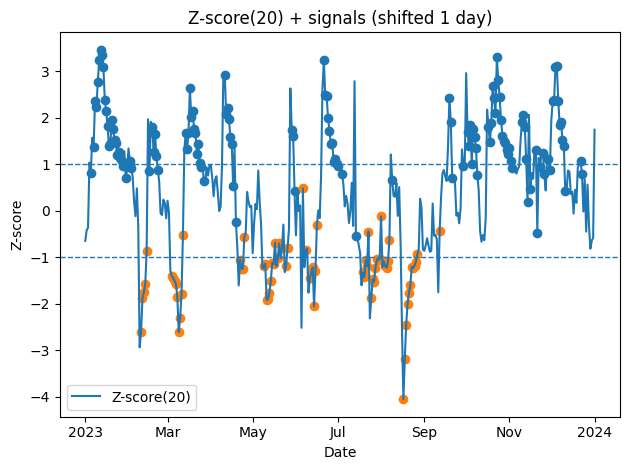

In [ ]:

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# Chọn đoạn gần đây để dễ nhìn
recent_days = 365
view = df.merge(sig[["timestamp","sig_rsi","sig_sma","sig_z"]], on="timestamp", how="left")
view = view[view["timestamp"] >= (view["timestamp"].max() - pd.Timedelta(days=recent_days))].copy()

# 1) SMA crossover + Close
plt.figure()
plt.plot(view["timestamp"], view["close"], label="Close")
plt.plot(view["timestamp"], view["sma20"], label="SMA20")
plt.plot(view["timestamp"], view["sma50"], label="SMA50")
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.ConciseDateFormatter(mdates.AutoDateLocator()))
plt.title("SMA20 vs SMA50 (trend signal shown in next plots)")
plt.xlabel("Date"); plt.ylabel("Price"); plt.legend(); plt.tight_layout(); plt.show()

# 2) RSI(14) với bands + điểm vào theo sig_rsi
plt.figure()
plt.plot(view["timestamp"], view["rsi14"], label="RSI(14)")
plt.axhline(70, linestyle="--", linewidth=1); plt.axhline(30, linestyle="--", linewidth=1)
# đánh dấu điểm tín hiệu (long=1, short=-1)
plt.scatter(view.loc[view["sig_rsi"]==1, "timestamp"], view.loc[view["sig_rsi"]==1, "rsi14"])
plt.scatter(view.loc[view["sig_rsi"]==-1,"timestamp"], view.loc[view["sig_rsi"]==-1,"rsi14"])
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.ConciseDateFormatter(mdates.AutoDateLocator()))
plt.title("RSI(14) + signals (shifted 1 day)")
plt.xlabel("Date"); plt.ylabel("RSI"); plt.legend(); plt.tight_layout(); plt.show()

# 3) Z-score + ngưỡng
plt.figure()
plt.plot(view["timestamp"], view["zscore20"], label="Z-score(20)")
plt.axhline(1.0, linestyle="--", linewidth=1); plt.axhline(-1.0, linestyle="--", linewidth=1)
plt.scatter(view.loc[view["sig_z"]==1, "timestamp"], view.loc[view["sig_z"]==1, "zscore20"])
plt.scatter(view.loc[view["sig_z"]==-1,"timestamp"], view.loc[view["sig_z"]==-1,"zscore20"])
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.ConciseDateFormatter(mdates.AutoDateLocator()))
plt.title("Z-score(20) + signals (shifted 1 day)")
plt.xlabel("Date"); plt.ylabel("Z-score"); plt.legend(); plt.tight_layout(); plt.show()


### Cell 5 — Basic Position Sizing (full exposure & fixed % equity)

- **Mục tiêu:** Chuyển **tín hiệu** (`sig_rsi/sig_sma/sig_z`) thành **vị thế** và **đường vốn** để chuẩn bị backtest.
- **Dữ liệu vào:**
  - `ret = close.pct_change()` — lợi nhuận ngày.
  - Tín hiệu đã **shift(1)** (không lookahead): dùng tín hiệu hôm nay cho lệnh **ngày mai**.
- **2 cách phân bổ vốn:**
  1) **Full exposure**: `pos ∈ {-1, 0, +1}`  
     - `pnl_full = pos.shift(1) * ret`  
     - `equity_full = (1 + pnl_full).cumprod()`
  2) **Fixed % equity** (ví dụ `RISK_PCT=0.2`):  
     - Mỗi ngày nhắm **±k% vốn** theo hướng tín hiệu → quy ra **units = (k% * equity) / price**  
     - `pnl_fp = units.shift(1) * ret`  
     - `equity_fp = (1 + pnl_fp).cumprod()`
- **Giả định:** Chưa tính **fee/slippage**, 1 tài sản (BTC) đơn giản để minh hoạ.
- **Tùy chỉnh:** Đổi `SIG_COL` (chọn `sig_rsi`/`sig_sma`/`sig_z`) và `RISK_PCT` theo ý tưởng chiến lược.
- **Đầu ra:** In `Final equity` cho 2 phương án + bảng tail để kiểm tra logic.


In [ ]:
# CELL 5 — Basic Position Sizing: full exposure & fixed % equity (no fees/slippage)

import numpy as np
import pandas as pd

bt = df.merge(sig[["timestamp","sig_rsi","sig_sma","sig_z"]], on="timestamp", how="left").copy()
bt["ret"] = bt["close"].pct_change().fillna(0.0)

# chọn 1 tín hiệu để demo (có thể đổi 'sig_rsi'/'sig_sma'/'sig_z')
SIG_COL = "sig_sma"

# ---- 1) Full exposure: vào full 1x khi tín hiệu != 0 ----
# position = {-1,0,1} đã shift(1) ở cell 3
bt["pos_full"] = bt[SIG_COL].fillna(0.0)  # -1/0/1
bt["pnl_full"] = bt["pos_full"].shift(1).fillna(0.0) * bt["ret"]              # no lookahead
bt["equity_full"] = (1.0 + bt["pnl_full"]).cumprod()

# ---- 2) Fixed % equity: vào k% vốn, quy về notional trên giá ----
RISK_PCT = 0.2  # 20% vốn mỗi lệnh theo hướng tín hiệu
bt["equity_fp"] = 1.0
units_prev = 0.0

equity = 1.0
units_list = [0.0]

for i in range(1, len(bt)):
    # cập nhật equity theo vị thế hôm qua
    equity *= (1.0 + units_prev * bt.loc[i, "ret"])
    # tính target units cho hôm nay dựa trên % vốn
    sig = bt.loc[i, SIG_COL] if pd.notna(bt.loc[i, SIG_COL]) else 0.0
    price = bt.loc[i, "close"]
    target_notional = equity * RISK_PCT * np.sign(sig)  # +/- k% vốn
    target_units = 0.0 if price == 0 or np.isnan(price) else target_notional / price
    units_prev = target_units
    units_list.append(units_prev)

bt["units_fp"] = units_list
# PnL fixed % (dùng units hôm qua)
bt["pnl_fp"] = bt["units_fp"].shift(1).fillna(0.0) * bt["ret"]
bt["equity_fp"] = (1.0 + bt["pnl_fp"]).cumprod()

# ---- Tóm tắt nhanh ----
print("[Final equity]")
print("Full exposure :", float(bt["equity_full"].iloc[-1]))
print("Fixed % equity:", float(bt["equity_fp"].iloc[-1]))

bt[["timestamp","close",SIG_COL,"pos_full","equity_full","units_fp","equity_fp"]].tail(8)


[Final equity]
Full exposure : 2.1605378550577474
Fixed % equity: 1.0000061152409174


,timestamp,close,sig_sma,pos_full,equity_full,units_fp,equity_fp
1569,2023-12-25 00:00:00+00:00,43611.9,1.0,1.0,2.130335,0.000005,1.000006
1570,2023-12-26 00:00:00+00:00,42538.5,1.0,1.0,2.077902,0.000005,1.000006
1571,2023-12-27 00:00:00+00:00,43453.8,1.0,1.0,2.122613,0.000005,1.000006
1572,2023-12-28 00:00:00+00:00,42600.1,1.0,1.0,2.080911,0.000005,1.000006
1573,2023-12-29 00:00:00+00:00,42095.1,1.0,1.0,2.056243,0.000005,1.000006
1574,2023-12-30 00:00:00+00:00,42174.2,1.0,1.0,2.060107,0.000005,1.000006
1575,2023-12-31 00:00:00+00:00,42314.0,1.0,1.0,2.066936,0.000005,1.000006
1576,2024-01-01 00:00:00+00:00,44230.2,1.0,1.0,2.160538,0.000005,1.000006
